In [1]:
import sys
import os

project_root = r"C:\Users\jonas\Desktop\Weiterbildung\Projekt\nba_shot_predictions"
if project_root not in sys.path:
    sys.path.append(project_root)

from app.data_providers import test_train_dataset
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

from sklearn.calibration import calibration_curve

from xgboost import XGBClassifier

import joblib

pd.set_option('display.max_columns', None)

# Helper functions

In [2]:
# Define feature set and functions
cols_OneHot = ['PLAYER_NAME', 'is_playoffs', 'MAIN_ACTION_TYPE']
cols_targetEncode = ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']

def select_features(df_):
    feature_set_reduced = ['MAIN_ACTION_TYPE',
    'SHOT_DISTANCE',
    'PLAYER_NAME',
    'LOC_Y',
    'points',
    'year',
    'ABS_ANGLE',
    'TimeRemainingInPeriod',
    'PLAYER1_TEAM_ABBREVIATION',
    'TotalPlayedTime',
    'Opponent_team_abbreviation',
    'TimeRemainingInGame',
    'IS_HOME',
    'scoreMarginBeforeShot', # not because of feature importance, but it seems relevant
    'IsOvertime', # not because of feature importance, but it seems relevant
    'is_playoffs', # not because of feature importance, but it seems relevant
    ]
    return df_[feature_set_reduced]

def add_additional_features(df_): 
    if not pd.api.types.is_datetime64_any_dtype(df_['GAME_DATE']):

        df_['GAME_DATE'] = pd.to_datetime(
            df_['GAME_DATE'].astype(str),
            format='%Y%m%d',
            errors='coerce'
        )
    df_['year'] = df_['GAME_DATE'].dt.year
    df_['month'] = df_['GAME_DATE'].dt.month
    df_['day'] = df_['GAME_DATE'].dt.weekday

    df_['Opponent_team_abbreviation'] = df_['HTM']
    df_.loc[X_train['IS_HOME'] == 0, 'Opponent_team_abbreviation'] = df_.loc[df_['IS_HOME'] == 0, 'VTM']

    return df_

# Model and data import

In [3]:
# Import pipeline
pipeline = joblib.load(r'../models/nba_shot_model_pipeline.pkl')
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...0011BCA90F9C0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

## Model overview:
- Add additional features:
    - year
    - opponent team abbreviation
- Select features:
    - ['MAIN_ACTION_TYPE',
    'SHOT_DISTANCE',
    'PLAYER_NAME',
    'LOC_Y',
    'points',
    'year',
    'ABS_ANGLE',
    'TimeRemainingInPeriod',
    'PLAYER1_TEAM_ABBREVIATION',
    'TotalPlayedTime',
    'Opponent_team_abbreviation',
    'TimeRemainingInGame',
    'IS_HOME',
    'scoreMarginBeforeShot',
    'IsOvertime',
    'is_playoffs']
- Encoding:
    - OneHotEncoding:
        ['PLAYER_NAME', 'is_playoffs', 'MAIN_ACTION_TYPE']
    - TargetEncoding:
        ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']
- Model:
    - XGboost classifier    

## Data import and prediction

In [4]:
# Import data
data = test_train_dataset()
X_train = data['train'].drop('SHOT_MADE_FLAG', axis=1)
y_train = data['train']['SHOT_MADE_FLAG']

X_test = data['test'].drop('SHOT_MADE_FLAG', axis=1)
y_test = data['test']['SHOT_MADE_FLAG']

Repo card metadata block was not found. Setting CardData to empty.


In [5]:
y_test_pred = pipeline.predict(X_test)
y_test_proba_pred = pipeline.predict_proba(X_test)

In [6]:
print(roc_auc_score(y_test, y_test_proba_pred[:,1]))
display(pd.crosstab(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

0.7220277628777276


col_0,0,1
SHOT_MADE_FLAG,,
0.0,32049,14388
1.0,21463,39782


              precision    recall  f1-score   support

         0.0       0.60      0.69      0.64     46437
         1.0       0.73      0.65      0.69     61245

    accuracy                           0.67    107682
   macro avg       0.67      0.67      0.67    107682
weighted avg       0.68      0.67      0.67    107682



In [7]:
# Build error Dataframe

error_df = X_test.copy()

error_df["y_true"] = y_test.values
error_df["y_pred"] = y_test_pred
error_df["y_pred_proba"] = y_test_proba_pred[:, 1]

# confidence
error_df["confidence"] = np.where(
    error_df["y_pred"] == 1,
    error_df["y_pred_proba"],
    1 - error_df["y_pred_proba"]
)

error_df["correct"] = (
    error_df["y_true"] == error_df["y_pred"]
)

# prediction error magnitude
error_df["error"] = abs(error_df["y_true"] - error_df["y_pred_proba"])

# Check worst predictions

In [33]:
# Check worst predictions: Wrong, but with high confidence

worst_predictions = (
    error_df[~error_df["correct"]]
    .sort_values("confidence", ascending=False)
)

worst_predictions = worst_predictions.loc[worst_predictions['confidence'] > 0.75, :]

worst_predictions.loc[:,
    [
        "PLAYER_NAME",
        "ACTION_TYPE",
        "MAIN_ACTION_TYPE",
        "SHOT_DISTANCE",
        "ABS_ANGLE",
        "LOC_X",
        "LOC_Y",
        "scoreMarginBeforeShot",
        "TimeRemainingInPeriod",
        "y_true",
        "y_pred",
        "y_pred_proba",
        "confidence"
    ]
]

,PLAYER_NAME,ACTION_TYPE,MAIN_ACTION_TYPE,SHOT_DISTANCE,ABS_ANGLE,LOC_X,LOC_Y,scoreMarginBeforeShot,TimeRemainingInPeriod,y_true,y_pred,y_pred_proba,confidence
86491,Chris Paul,Running Jump Shot,Jump,60.0,11.458752,-120.0,592.0,26.0,0,1.0,0,0.055131,0.944869
17226,Manu Ginobili,Jump Bank Shot,Jump,51.0,24.343484,-214.0,473.0,7.0,0,1.0,0,0.059190,0.940810
65543,Dwyane Wade,Jump Shot,Jump,49.0,0.000000,0.0,493.0,7.0,0,1.0,0,0.063615,0.936385
68549,Kevin Durant,Driving Dunk Shot,Dunk,0.0,0.000000,0.0,1.0,4.0,104,0.0,1,0.933978,0.933978
70546,Kevin Durant,Dunk Shot,Dunk,0.0,0.000000,0.0,1.0,14.0,272,0.0,1,0.933880,0.933880
...,...,...,...,...,...,...,...,...,...,...,...,...,...
104077,LeBron James,Free Throw,Other,15.0,0.000000,0.0,15.0,12.0,610,0.0,1,0.750146,0.750146
88742,LeBron James,Free Throw,Other,15.0,0.000000,0.0,15.0,29.0,424,0.0,1,0.750120,0.750120
89595,LeBron James,Free Throw,Other,15.0,0.000000,0.0,15.0,19.0,222,0.0,1,0.750120,0.750120
88739,LeBron James,Free Throw,Other,15.0,0.000000,0.0,15.0,29.0,188,0.0,1,0.750027,0.750027


In [40]:
action_dist_full = error_df['ACTION_TYPE'].value_counts(normalize=True)
action_dist_error = error_df['ACTION_TYPE'].loc[~error_df["correct"]].value_counts(normalize=True)
action_dist_worst = worst_predictions['ACTION_TYPE'].loc[~worst_predictions["correct"]].value_counts(normalize=True)

main_action_dist_full = error_df['MAIN_ACTION_TYPE'].value_counts(normalize=True)
main_action_dist_error = error_df['MAIN_ACTION_TYPE'].loc[~error_df["correct"]].value_counts(normalize=True)
main_action_dist_worst = worst_predictions['MAIN_ACTION_TYPE'].loc[~worst_predictions["correct"]].value_counts(normalize=True)

action_compare = pd.concat([
    action_dist_full.rename("full_distribution"),
    action_dist_error.rename("error_distribution"),
    action_dist_worst.rename("worst_distribution"),
    ],
    axis=1
).fillna(0)

main_action_compare = pd.concat([
    main_action_dist_full.rename("full_distribution_main"),
    main_action_dist_error.rename("error_distribution_main"),
    main_action_dist_worst.rename("worst_distribution_main"),
    ],
    axis=1
).fillna(0)

action_compare['difference_errors'] = action_compare['error_distribution'] - action_compare['full_distribution']
action_compare['difference_worst_errors'] = action_compare['worst_distribution'] - action_compare['full_distribution']
main_action_compare['difference_main_errors'] = main_action_compare['error_distribution_main'] - main_action_compare['full_distribution_main']
main_action_compare['difference_main_worst_errors'] = main_action_compare['worst_distribution_main'] - main_action_compare['full_distribution_main']

action_compare = action_compare.sort_values(by=['difference_errors'], ascending=False)
main_action_compare = main_action_compare.sort_values(by=['difference_main_errors'], ascending=False)

print("Sorted by biggest difference in all errors: \n")
display(action_compare.head(10))
display(main_action_compare)

print("Sorted by biggest difference in worst errors: \n")
display(action_compare.sort_values(by=['difference_worst_errors'], ascending=False).head(10))
display(main_action_compare.sort_values(by=['difference_main_worst_errors'], ascending=False))

Sorted by biggest difference in all errors: 



,full_distribution,error_distribution,worst_distribution,difference_errors,difference_worst_errors
ACTION_TYPE,,,,,
Layup Shot,0.065619,0.095339,0.003004,0.029720,-0.062615
Pullup Jump shot,0.049869,0.073945,0.002575,0.024076,-0.047295
Jump Shot,0.315652,0.335890,0.008796,0.020239,-0.306855
Running Jump Shot,0.012918,0.022398,0.001073,0.009481,-0.011845
Turnaround Jump Shot,0.019613,0.028953,0.000215,0.009340,-0.019399
Step Back Jump shot,0.026597,0.035145,0.000429,0.008549,-0.026168
Fadeaway Jump Shot,0.019725,0.027977,0.000000,0.008252,-0.019725
Jump Bank Shot,0.007745,0.013863,0.000429,0.006118,-0.007316
Turnaround Fadeaway shot,0.010949,0.015397,0.000000,0.004448,-0.010949


,full_distribution_main,error_distribution_main,worst_distribution_main,difference_main_errors,difference_main_worst_errors
MAIN_ACTION_TYPE,,,,,
Jump,0.480220,0.578003,0.013946,0.097784,-0.466274
Layup,0.170892,0.196145,0.008153,0.025253,-0.162739
Hook,0.017329,0.023458,0.000000,0.006129,-0.017329
Dunk,0.037843,0.008396,0.062004,-0.029447,0.024161
Other,0.293717,0.193997,0.915898,-0.099719,0.622181


Sorted by biggest difference in worst errors: 



,full_distribution,error_distribution,worst_distribution,difference_errors,difference_worst_errors
ACTION_TYPE,,,,,
Free Throw,0.270723,0.164793,0.915898,-0.105930,0.645175
Dunk Shot,0.010271,0.003821,0.028964,-0.006450,0.018693
Driving Dunk Shot,0.007374,0.001813,0.012873,-0.005561,0.005499
Alley Oop Dunk Shot,0.004411,0.000948,0.007080,-0.003463,0.002669
Putback Dunk Shot,0.001207,0.000446,0.003433,-0.000761,0.002225
Reverse Dunk Shot,0.000576,0.000139,0.001073,-0.000436,0.000497
Tip Dunk Shot,0.000436,0.000112,0.000858,-0.000325,0.000422
Follow Up Dunk Shot,0.000139,0.000056,0.000429,-0.000084,0.000290
Running Alley Oop Dunk Shot,0.000269,0.000056,0.000429,-0.000214,0.000160


,full_distribution_main,error_distribution_main,worst_distribution_main,difference_main_errors,difference_main_worst_errors
MAIN_ACTION_TYPE,,,,,
Other,0.293717,0.193997,0.915898,-0.099719,0.622181
Dunk,0.037843,0.008396,0.062004,-0.029447,0.024161
Hook,0.017329,0.023458,0.000000,0.006129,-0.017329
Layup,0.170892,0.196145,0.008153,0.025253,-0.162739
Jump,0.480220,0.578003,0.013946,0.097784,-0.466274


In [51]:
def calc_error_rate_by_feature(error_df, column_name):
    out_error_rate = pd.DataFrame()
    out_error_rate = (error_df.groupby(column_name).agg(n=("correct", "size"), accuracy=("correct", "mean")))
    out_error_rate["error_rate"] = (1 - out_error_rate["accuracy"])
    out_error_rate = (out_error_rate[out_error_rate["n"] >= 20].sort_values("error_rate", ascending=False))
    return out_error_rate

In [52]:
print("Error Rate by Action type: ")
display(calc_error_rate_by_feature(error_df, "ACTION_TYPE"))

print("Error Rate by Main action type: ")
display(calc_error_rate_by_feature(error_df, "MAIN_ACTION_TYPE"))

Error Rate by Action type: 


,n,accuracy,error_rate
ACTION_TYPE,,,
Jump Bank Shot,834,0.404077,0.595923
Running Jump Shot,1391,0.422717,0.577283
Driving Floating Bank Jump Shot,312,0.435897,0.564103
Hook Shot,817,0.481028,0.518972
Driving Jump shot,164,0.506098,0.493902
Pullup Jump shot,5370,0.506331,0.493669
Turnaround Jump Shot,2112,0.508523,0.491477
Layup Shot,7066,0.516275,0.483725
Turnaround Fadeaway Bank Jump Shot,77,0.519481,0.480519


Error Rate by Main action type: 


,n,accuracy,error_rate
MAIN_ACTION_TYPE,,,
Hook,1866,0.549303,0.450697
Jump,51711,0.599273,0.400727
Layup,18402,0.617868,0.382132
Other,31628,0.780100,0.219900
Dunk,4075,0.926135,0.073865


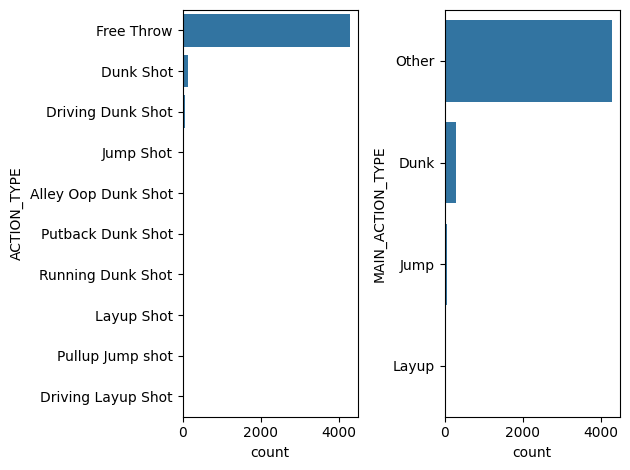

In [54]:
plt.subplot(121)
sns.countplot(worst_predictions, y='ACTION_TYPE', order=worst_predictions['ACTION_TYPE'].value_counts().iloc[:10].index)

plt.subplot(122)
sns.countplot(worst_predictions, y='MAIN_ACTION_TYPE', order=worst_predictions['MAIN_ACTION_TYPE'].value_counts().iloc[:10].index)

plt.tight_layout()

# Check prediction per shot type

In [57]:
freethrow_df = error_df.loc[error_df['ACTION_TYPE'] == 'Free Throw']
pd.crosstab(freethrow_df['y_true'], freethrow_df['y_pred'])

y_pred,1
y_true,
0.0,5908
1.0,23244


In [59]:
for action_type in error_df["MAIN_ACTION_TYPE"].value_counts().index[:15]:

    subset = error_df[
        error_df["MAIN_ACTION_TYPE"] == action_type
    ]

    accuracy = (
        subset["y_true"] == subset["y_pred"]
    ).mean()

    print("\n" + "="*60)
    print(f"{action_type}")
    print(f"n = {len(subset)}")
    print(f"accuracy = {accuracy:.3f}")
    print("="*60)

    cm = pd.crosstab(
        subset["y_true"],
        subset["y_pred"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )

    display(cm)


Jump
n = 51711
accuracy = 0.599


Predicted,0,1
Actual,,
0.0,30486,423
1.0,20299,503



Other
n = 31628
accuracy = 0.780


Predicted,0,1
Actual,,
0.0,215,6798
1.0,157,24458



Layup
n = 18402
accuracy = 0.618


Predicted,0,1
Actual,,
0.0,1169,6171
1.0,861,10201



Dunk
n = 4075
accuracy = 0.926


Predicted,1
Actual,
0.0,301
1.0,3774



Hook
n = 1866
accuracy = 0.549


Predicted,0,1
Actual,,
0.0,179,695
1.0,146,846


In [58]:
for action_type in error_df["ACTION_TYPE"].value_counts().index[:15]:

    subset = error_df[
        error_df["ACTION_TYPE"] == action_type
    ]

    accuracy = (
        subset["y_true"] == subset["y_pred"]
    ).mean()

    print("\n" + "="*60)
    print(f"{action_type}")
    print(f"n = {len(subset)}")
    print(f"accuracy = {accuracy:.3f}")
    print("="*60)

    cm = pd.crosstab(
        subset["y_true"],
        subset["y_pred"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )

    display(cm)


Jump Shot
n = 33990
accuracy = 0.646


Predicted,0,1
Actual,,
0.0,21836,152
1.0,11890,112



Free Throw
n = 29152
accuracy = 0.797


Predicted,1
Actual,
0.0,5908
1.0,23244



Layup Shot
n = 7066
accuracy = 0.516


Predicted,0,1
Actual,,
0.0,325,3280
1.0,138,3323



Driving Layup Shot
n = 6007
accuracy = 0.682


Predicted,0,1
Actual,,
0.0,532,1554
1.0,355,3566



Pullup Jump shot
n = 5370
accuracy = 0.506


Predicted,0,1
Actual,,
0.0,2606,92
1.0,2559,113



Step Back Jump shot
n = 2864
accuracy = 0.560


Predicted,0,1
Actual,,
0.0,1585,12
1.0,1248,19



Fadeaway Jump Shot
n = 2124
accuracy = 0.528


Predicted,0,1
Actual,,
0.0,1087,27
1.0,976,34



Turnaround Jump Shot
n = 2112
accuracy = 0.509


Predicted,0,1
Actual,,
0.0,1049,32
1.0,1006,25



Running Jump Shot
n = 1391
accuracy = 0.423


Predicted,0,1
Actual,,
0.0,565,9
1.0,794,23



Turnaround Fadeaway shot
n = 1179
accuracy = 0.532


Predicted,0,1
Actual,,
0.0,190,426
1.0,126,437



Floating Jump shot
n = 1130
accuracy = 0.532


Predicted,0,1
Actual,,
0.0,521,38
1.0,491,80



Dunk Shot
n = 1106
accuracy = 0.876


Predicted,1
Actual,
0.0,137
1.0,969



Driving Floating Jump Shot
n = 1042
accuracy = 0.545


Predicted,0,1
Actual,,
0.0,510,42
1.0,432,58



Driving Finger Roll Layup Shot
n = 1019
accuracy = 0.711


Predicted,0,1
Actual,,
0.0,81,178
1.0,117,643



Running Layup Shot
n = 980
accuracy = 0.681


Predicted,0,1
Actual,,
0.0,85,236
1.0,77,582


In [29]:
shottype_analysis = (
    error_df
    .groupby("MAIN_ACTION_TYPE")
    .agg(
        n_shots=("y_true", "size"),
        accuracy=("correct", "mean"),
        avg_error=("error", "mean"),
        avg_make_prob=("y_pred_proba", "mean")
    )
    .sort_values("avg_error", ascending=False)
)

shottype_analysis.head(20)

,n_shots,accuracy,avg_error,avg_make_prob
MAIN_ACTION_TYPE,,,,
Hook,1866,0.549303,0.493143,0.543963
Jump,51711,0.599273,0.476319,0.410025
Layup,18402,0.617868,0.463051,0.600068
Other,31628,0.780100,0.337206,0.768066
Dunk,4075,0.926135,0.155862,0.899973


## Conclusion for shot type:
- Worst predictions:
    - The model is very confident in predictions of free throws. In fact it only predicts hits for free throws.
    - This might be caused by the inbalance of different shot types in the data
    - After checking the same for other shot types, we see the model is predicting hit and miss almost only based on shot type
- All errors:
    - In terms of all errors, the model performs worst on jump shots. But this might be caused by the issue mentioned above, since jump shots are the most common
 
## Next Steps:
- Try with weighting per frequency of shot types
- Train one model per main shot type

# Other tests

In [16]:
# Player analysis

player_analysis = (
    error_df
    .groupby("PLAYER_NAME")
    .agg(
        n_shots=("y_true", "size"),
        accuracy=("correct", "mean"),
        avg_error=("error", "mean")
    )
)

player_analysis = (
    player_analysis[player_analysis["n_shots"] >= 50]
    .sort_values("avg_error", ascending=False)
)

player_analysis.head(20)

,n_shots,accuracy,avg_error
PLAYER_NAME,,,
Tony Parker,5105,0.640940,0.450090
Tim Duncan,6848,0.647342,0.445568
Kevin Garnett,5664,0.627119,0.438878
Luka Doncic,2620,0.647710,0.434391
Chris Paul,5451,0.645386,0.429740
Russell Westbrook,5954,0.669802,0.428275
Pau Gasol,5241,0.652738,0.428130
Draymond Green,2397,0.670421,0.427864
Stephen Curry,5354,0.643257,0.425742


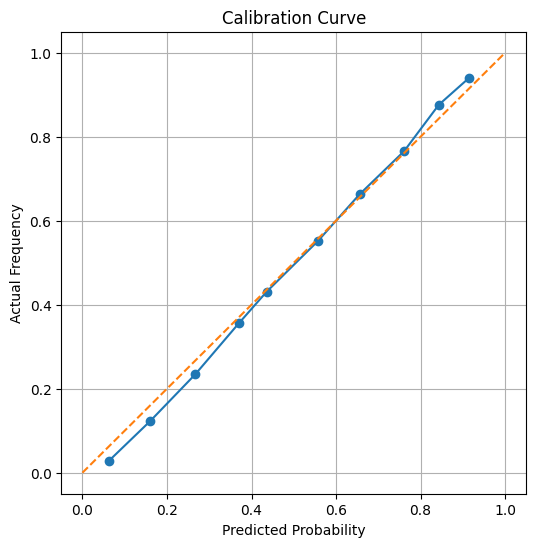

In [17]:
prob_true, prob_pred = calibration_curve(
    error_df["y_true"],
    error_df["y_pred_proba"],
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Frequency")
plt.title("Calibration Curve")

plt.grid(True)
plt.show()

In [18]:
# Distance analysis

distance_analysis = (
    error_df
    .groupby(pd.cut(error_df["SHOT_DISTANCE"], bins=10))
    .agg(
        accuracy=("correct", "mean"),
        avg_error=("error", "mean"),
        n=("y_true", "size")
    )
)

distance_analysis

,accuracy,avg_error,n
SHOT_DISTANCE,,,
"(-0.083, 8.3]",0.645775,0.431777,33171
"(8.3, 16.6]",0.716697,0.383249,45552
"(16.6, 24.9]",0.591287,0.481468,18064
"(24.9, 33.2]",0.643267,0.456638,10627
"(33.2, 41.5]",0.852174,0.246272,115
"(41.5, 49.8]",0.966102,0.104464,59
"(49.8, 58.1]",0.976744,0.078311,43
"(58.1, 66.4]",0.931034,0.114152,29
"(66.4, 74.7]",1.000000,0.055397,14
